# Driver Behavior Monitoring – Data Preparation and Model Training

This notebook contains the data preparation, feature engineering, model training, evaluation, and TensorFlow Lite export pipeline for the embedded driver behavior monitoring system.

The final model is intended for deployment on an ESP32 using TensorFlow Lite Micro.

## Workflow
1. Load trip data from HDF/HDF5 files
2. Inspect available CAN, GPS, and sensor signals
3. Build a feature set for driver behavior classification
4. Train and evaluate a compact neural network
5. Convert the trained model to quantized TensorFlow Lite
6. Export deployment artifacts for embedded inference


In [68]:
# =========================
# Setup and Imports
# =========================

import os
import json
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

## Data Access

The dataset is loaded from an HDF file.  
Update the path below to point to your local file or Google Drive location.

In [69]:
# =========================
# Data Path Configuration
# =========================

USE_GOOGLE_DRIVE = True

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

DATA_FILE = "/content/drive/MyDrive/dataset/20181113_Driver1_Trip1.hdf"

print("Using data file:")
print(DATA_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using data file:
/content/drive/MyDrive/dataset/20181113_Driver1_Trip1.hdf


## Inspect Top-Level HDF Structure

This step checks the main groups stored in the trip file.

In [70]:
# =========================
# Inspect HDF Structure
# =========================

with h5py.File(DATA_FILE, "r") as f:
    print("Top-level groups:")
    print(list(f.keys()))

Top-level groups:
['AI', 'CAN', 'GPS', 'Math', 'Plugins']


## Inspect Available Signals by Group

This step lists the contents of the major HDF groups such as CAN and GPS signals.

In [71]:
# =========================
# Inspect Signals Inside Each Group
# =========================

with h5py.File(DATA_FILE, "r") as f:
    for key in f.keys():
        print(f"\n{key}:")
        try:
            print(list(f[key].keys()))
        except AttributeError:
            print("No subkeys available")


AI:
['AI 1']

CAN:
['ASR', 'AccPedal', 'AirCondition', 'AirIntakeTemperature', 'AmbientTemperature', 'BoostPressure', 'BrkVoltage', 'CAN 1', 'ClutchStatus', 'ENG_Avus_Engineprotect', 'ENG_FuelTankCap_Lamp', 'ENG_Hotlamp', 'ENG_OBD2_Lamp', 'ENG_Particle_Lamp', 'ENG_Systemlamp', 'ENG_Text_Error_Fuelsys', 'ENG_Text_FuelTankCap_Warn', 'ENG_Text_MSG_Service', 'ENG_Text_Particlefil_Reg', 'ENG_TorqueIntegral', 'ENG_Trq_DMD', 'ENG_Trq_ZWR', 'ENG_Trq_m_ex', 'ENG_Winterdriveprog', 'EngineSpeed_CAN', 'EngineTemperature', 'Engine_02_BZ', 'Engine_02_CHK', 'FuelConsumption', 'GBX_Charisma_DrivePr', 'GBX_Charisma_Shift', 'GBX_Charisma_Status', 'GBX_Coding_MSG', 'GBX_EmergencyOperation', 'GBX_Enable_EngTrq_Demand', 'GBX_Enable_EngTrq_Intervention', 'GBX_Enable_Longterm_ProtectTrq', 'GBX_Enable_Synchro', 'GBX_EngTrq_Demand', 'GBX_EngTrq_Status', 'GBX_Increase_DMDRevs_Idle', 'GBX_Index_RunningResistance', 'GBX_InputSpeed', 'GBX_Kickdown_Error', 'GBX_LFR_Adaption', 'GBX_LimitCreepTrq', 'GBX_Longterm_Pro

## Build a Tabular Representation from a Single Trip

The raw HDF file stores each signal as a two-column array containing signal values and timestamps.  
This step extracts the relevant vehicle and inertial signals and converts them into a structured pandas DataFrame for analysis.

In [74]:
# =========================
# Load Relevant Signals from a Single Trip
# =========================

with h5py.File(DATA_FILE, "r") as f:
    df = pd.DataFrame({
        "time": np.array(f["CAN"]["VehicleSpeed"])[:, 1],
        "speed": np.array(f["CAN"]["VehicleSpeed"])[:, 0],
        "rpm": np.array(f["CAN"]["EngineSpeed_CAN"])[:, 0],
        "throttle": np.array(f["CAN"]["AccPedal"])[:, 0],
        "accel_long": np.array(f["Plugins"]["Body_acceleration_X"])[:, 0],
        "accel_lat": np.array(f["Plugins"]["Body_acceleration_Y"])[:, 0],
        "yaw_rate": np.array(f["Plugins"]["Gyroscope_Z"])[:, 0],
    })

print(f"Single-trip DataFrame shape: {df.shape}")
df.head()

Single-trip DataFrame shape: (158659, 7)


,time,speed,rpm,throttle,accel_long,accel_lat,yaw_rate
0,0.00,0.0,809.500000,0.0,0.009997,0.008148,0.039183
1,0.05,0.0,809.500000,0.0,0.021787,0.001331,-0.019813
2,0.10,0.0,810.215759,0.0,0.035207,0.018465,0.007516
3,0.15,0.0,807.657654,0.0,0.010243,0.009443,0.003027
4,0.20,0.0,805.500000,0.0,0.017022,-0.023953,-0.028922


In [75]:
# =========================
# Basic Summary of Single-Trip Signals
# =========================

print("Missing values per column:")
print(df.isnull().sum())

df[["speed", "rpm", "throttle", "accel_long", "accel_lat", "yaw_rate"]].describe()

Missing values per column:
time          0
speed         0
rpm           0
throttle      0
accel_long    0
accel_lat     0
yaw_rate      0
dtype: int64


,speed,rpm,throttle,accel_long,accel_lat,yaw_rate
count,158659.000000,158659.000000,158659.000000,158659.000000,158659.000000,158659.000000
mean,72.020050,1914.825195,19.904676,-0.002151,-0.000153,-0.018227
std,46.737667,676.555847,21.762764,0.445284,0.800918,2.902870
min,0.000000,676.500000,0.000000,-3.287427,-4.411313,-33.925224
25%,30.045543,1478.500000,0.000000,-0.142323,-0.240055,-0.503822
50%,82.800003,2000.961182,16.000000,-0.000101,0.000048,0.056152
75%,110.410004,2387.056274,36.469585,0.142448,0.230730,0.546929
max,141.338623,4918.850098,100.000000,3.501598,4.002303,30.114115


## Load and Combine All Trip Files

After validating the extraction process on a single trip, the same procedure is applied across all available trip files.  
Each trip is loaded into a DataFrame and tagged with its source filename before concatenation into a single dataset.

In [76]:
# =========================
# Discover Available Trip Files
# =========================

DATASET_DIR = "/content/drive/MyDrive/dataset"
files = sorted([f for f in os.listdir(DATASET_DIR) if f.endswith(".hdf")])

print(f"Total trip files found: {len(files)}")
files[:10]

Total trip files found: 21


['20181113_Driver1_Trip1.hdf',
 '20181113_Driver1_Trip2.hdf',
 '20181114_Driver2_Trip1.hdf',
 '20181114_Driver2_Trip2.hdf',
 '20181114_Driver2_Trip3.hdf',
 '20181114_Driver2_Trip4.hdf',
 '20181116_Driver1_Trip3.hdf',
 '20181116_Driver1_Trip4.hdf',
 '20181116_Driver1_Trip5.hdf',
 '20181116_Driver1_Trip6.hdf']

In [77]:
# =========================
# Function to Load a Single Trip
# =========================

def load_trip(file_path):
    with h5py.File(file_path, "r") as f:
        return pd.DataFrame({
            "time": np.array(f["CAN"]["VehicleSpeed"])[:, 1],
            "speed": np.array(f["CAN"]["VehicleSpeed"])[:, 0],
            "rpm": np.array(f["CAN"]["EngineSpeed_CAN"])[:, 0],
            "throttle": np.array(f["CAN"]["AccPedal"])[:, 0],
            "accel_long": np.array(f["Plugins"]["Body_acceleration_X"])[:, 0],
            "accel_lat": np.array(f["Plugins"]["Body_acceleration_Y"])[:, 0],
            "yaw_rate": np.array(f["Plugins"]["Gyroscope_Z"])[:, 0],
        })

In [78]:
# =========================
# Load and Concatenate All Trips
# =========================

all_trips = []
loaded_files = []
skipped_files = []

for file_name in files:
    file_path = os.path.join(DATASET_DIR, file_name)
    try:
        trip_df = load_trip(file_path)
        trip_df["trip"] = file_name
        all_trips.append(trip_df)
        loaded_files.append(file_name)
    except Exception as e:
        skipped_files.append((file_name, str(e)))

df_all = pd.concat(all_trips, ignore_index=True)

print(f"Loaded files: {len(loaded_files)}")
print(f"Skipped files: {len(skipped_files)}")
print(f"Combined dataset shape: {df_all.shape}")

Loaded files: 21
Skipped files: 0
Combined dataset shape: (873007, 8)


In [79]:
df_all.head()

,time,speed,rpm,throttle,accel_long,accel_lat,yaw_rate,trip
0,0.00,0.0,809.500000,0.0,0.009997,0.008148,0.039183,20181113_Driver1_Trip1.hdf
1,0.05,0.0,809.500000,0.0,0.021787,0.001331,-0.019813,20181113_Driver1_Trip1.hdf
2,0.10,0.0,810.215759,0.0,0.035207,0.018465,0.007516,20181113_Driver1_Trip1.hdf
3,0.15,0.0,807.657654,0.0,0.010243,0.009443,0.003027,20181113_Driver1_Trip1.hdf
4,0.20,0.0,805.500000,0.0,0.017022,-0.023953,-0.028922,20181113_Driver1_Trip1.hdf


## Basic Signal Preprocessing

A short rolling-average filter is applied to selected inertial signals to reduce noise before downstream feature engineering.

In [80]:
# =========================
# Light Signal Smoothing
# =========================

def smooth_signal(x, window=5):
    return x.rolling(window=window, center=True, min_periods=1).mean()

df_all["accel_long_f"] = smooth_signal(df_all["accel_long"])
df_all["accel_lat_f"] = smooth_signal(df_all["accel_lat"])
df_all["yaw_rate_f"] = smooth_signal(df_all["yaw_rate"])

## Simple Vehicle-State Indicators

Binary indicators are created for basic vehicle state interpretation, such as whether the vehicle is moving or whether throttle input is active.  
These may be used for exploratory analysis or as auxiliary features.

In [81]:
# =========================
# Simple Driving-State Indicators
# =========================

df_all["moving"] = df_all["speed"] > 10
df_all["throttle_on"] = df_all["throttle"] > 10

df_all[["speed", "moving", "throttle", "throttle_on"]].head()

,speed,moving,throttle,throttle_on
0,0.0,False,0.0,False
1,0.0,False,0.0,False
2,0.0,False,0.0,False
3,0.0,False,0.0,False
4,0.0,False,0.0,False


In [82]:
print(df_all.shape)
df_all.head()

(873007, 13)


,time,speed,rpm,throttle,accel_long,accel_lat,yaw_rate,trip,accel_long_f,accel_lat_f,yaw_rate_f,moving,throttle_on
0,0.00,0.0,809.500000,0.0,0.009997,0.008148,0.039183,20181113_Driver1_Trip1.hdf,0.022330,0.009315,0.008962,False,False
1,0.05,0.0,809.500000,0.0,0.021787,0.001331,-0.019813,20181113_Driver1_Trip1.hdf,0.019309,0.009347,0.007478,False,False
2,0.10,0.0,810.215759,0.0,0.035207,0.018465,0.007516,20181113_Driver1_Trip1.hdf,0.018851,0.002687,0.000198,False,False
3,0.15,0.0,807.657654,0.0,0.010243,0.009443,0.003027,20181113_Driver1_Trip1.hdf,0.022815,-0.000630,-0.010664,False,False
4,0.20,0.0,805.500000,0.0,0.017022,-0.023953,-0.028922,20181113_Driver1_Trip1.hdf,0.020613,-0.000749,-0.004573,False,False


## Event Labeling Using Threshold-Based Rules

This section generates rule-based labels for harsh driving events using threshold conditions applied to the processed trip signals.  
The aim is to identify episodes of harsh acceleration, harsh braking, and harsh cornering, and then combine them into a binary aggressive-driving label.

In [83]:
# =========================
# Event Detection Thresholds
# =========================

HARSH_ACCEL_THRESHOLD = 2.5        # m/s^2
HARSH_BRAKE_THRESHOLD = -2.5       # m/s^2
HARSH_CORNER_LAT_THRESHOLD = 3.0   # m/s^2
HARSH_CORNER_YAW_THRESHOLD = 0.4   # rad/s

MIN_SPEED_ACCEL = 10               # km/h
MIN_SPEED_BRAKE = 20               # km/h
MIN_SPEED_CORNER = 15              # km/h

MIN_CONSECUTIVE_SAMPLES = 10       # ~0.5 s at 20 Hz

## Helper Functions

Two helper functions are used in the event-labeling pipeline:
- a smoothing function for reducing short-term noise
- a duration filter that removes brief transient threshold crossings

In [84]:
# =========================
# Helper Functions
# =========================

def smooth_signal(x, window=5):
    """Apply rolling-average smoothing."""
    return x.rolling(window=window, center=True, min_periods=1).mean()


def sustained_event(mask, min_samples=10):
    """
    Keep only runs of True values that last at least min_samples.
    This suppresses short transient threshold crossings.
    """
    mask = mask.astype(int).to_numpy()
    out = np.zeros_like(mask)

    start = None
    for i, v in enumerate(mask):
        if v == 1 and start is None:
            start = i
        elif v == 0 and start is not None:
            if i - start >= min_samples:
                out[start:i] = 1
            start = None

    if start is not None and len(mask) - start >= min_samples:
        out[start:] = 1

    return out

## Trip-Level Event Detection

For each trip:
- longitudinal acceleration is derived from speed
- inertial signals are smoothed
- threshold rules are applied
- short threshold crossings are filtered out
- a binary aggressive-driving label is created

In [85]:
# =========================
# Trip-Level Event Detection
# =========================

def process_trip_events(trip_df):
    trip_df = trip_df.copy().sort_values("time").reset_index(drop=True)

    # Sampling interval
    dt = trip_df["time"].diff().fillna(0.05)
    dt = dt.replace(0, 0.05)

    # Derive longitudinal acceleration from speed
    speed_ms = trip_df["speed"] / 3.6
    trip_df["accel_long_derived"] = speed_ms.diff().fillna(0) / dt

    # Smooth selected signals
    trip_df["accel_long_smooth"] = smooth_signal(trip_df["accel_long_derived"], window=5)
    trip_df["accel_lat_smooth"] = smooth_signal(trip_df["accel_lat"], window=5)
    trip_df["yaw_rate_smooth"] = smooth_signal(trip_df["yaw_rate"], window=5)

    # Raw threshold crossings
    harsh_accel_raw = (
        (trip_df["accel_long_smooth"] > HARSH_ACCEL_THRESHOLD) &
        (trip_df["speed"] > MIN_SPEED_ACCEL)
    )

    harsh_brake_raw = (
        (trip_df["accel_long_smooth"] < HARSH_BRAKE_THRESHOLD) &
        (trip_df["speed"] > MIN_SPEED_BRAKE)
    )

    harsh_corner_raw = (
        (trip_df["accel_lat_smooth"].abs() > HARSH_CORNER_LAT_THRESHOLD) &
        (trip_df["yaw_rate_smooth"].abs() > HARSH_CORNER_YAW_THRESHOLD) &
        (trip_df["speed"] > MIN_SPEED_CORNER)
    )

    # Duration filtering
    trip_df["harsh_accel"] = sustained_event(
        harsh_accel_raw, min_samples=MIN_CONSECUTIVE_SAMPLES
    )
    trip_df["harsh_brake"] = sustained_event(
        harsh_brake_raw, min_samples=MIN_CONSECUTIVE_SAMPLES
    )
    trip_df["harsh_corner"] = sustained_event(
        harsh_corner_raw, min_samples=MIN_CONSECUTIVE_SAMPLES
    )

    # Aggregate aggressive label
    trip_df["aggressive"] = (
        (trip_df["harsh_accel"] == 1) |
        (trip_df["harsh_brake"] == 1) |
        (trip_df["harsh_corner"] == 1)
    ).astype(int)

    return trip_df

## Apply Event Detection Across All Trips

The event-detection function is applied independently to each trip before recombining the processed outputs into a single labeled dataset.

In [86]:
# =========================
# Apply Event Detection to All Trips
# =========================

processed_trips = []

for trip_name, trip_df in df_all.groupby("trip"):
    processed_trips.append(process_trip_events(trip_df))

df_all = pd.concat(processed_trips, ignore_index=True)

print(f"Processed dataset shape: {df_all.shape}")

Processed dataset shape: (873007, 21)


## Label Distribution Summary

This step summarizes the frequency of the detected event labels across the full dataset.

In [87]:
# =========================
# Overall Label Summary
# =========================

label_counts = df_all[["harsh_accel", "harsh_brake", "harsh_corner", "aggressive"]].sum()
label_counts

,0
harsh_accel,2348
harsh_brake,1560
harsh_corner,4493
aggressive,8348


## Trip-Level Event Summary

To account for differences in trip duration, event episodes are counted and normalized by trip length.  
This provides a more comparable view of aggressive driving across trips and drivers.

In [88]:
# =========================
# Count Distinct Event Episodes
# =========================

def count_event_episodes(series):
    """Count distinct event episodes, where consecutive 1s are treated as one event."""
    s = np.asarray(series, dtype=int)
    return int(((s[1:] == 1) & (s[:-1] == 0)).sum() + (s[0] == 1))

In [90]:
# =========================
# Build Trip-Level Summary Table
# =========================

summary = []

for trip_name, trip_df in df_all.groupby("trip"):
    trip_duration_sec = trip_df["time"].max() - trip_df["time"].min()
    trip_duration_min = trip_duration_sec / 60 if trip_duration_sec > 0 else 0

    accel_events = count_event_episodes(trip_df["harsh_accel"])
    brake_events = count_event_episodes(trip_df["harsh_brake"])
    corner_events = count_event_episodes(trip_df["harsh_corner"])
    total_events = accel_events + brake_events + corner_events

    summary.append({
        "trip": trip_name,
        "driver": trip_name.split("_")[1],
        "harsh_accel_events": accel_events,
        "harsh_brake_events": brake_events,
        "harsh_corner_events": corner_events,
        "total_events": total_events,
        "trip_duration_sec": trip_duration_sec,
        "trip_duration_min": trip_duration_min,
        "events_per_min": total_events / trip_duration_min if trip_duration_min > 0 else 0,
        "accel_per_min": accel_events / trip_duration_min if trip_duration_min > 0 else 0,
        "brake_per_min": brake_events / trip_duration_min if trip_duration_min > 0 else 0,
        "corner_per_min": corner_events / trip_duration_min if trip_duration_min > 0 else 0,
    })

summary_df = pd.DataFrame(summary)
summary_df.head()

,trip,driver,harsh_accel_events,harsh_brake_events,harsh_corner_events,total_events,trip_duration_sec,trip_duration_min,events_per_min,accel_per_min,brake_per_min,corner_per_min
0,20181113_Driver1_Trip1.hdf,Driver1,0,6,38,44,7932.899902,132.214998,0.332791,0.000000,0.045381,0.287411
1,20181113_Driver1_Trip2.hdf,Driver1,6,2,7,15,2741.699951,45.694999,0.328263,0.131305,0.043768,0.153190
2,20181114_Driver2_Trip1.hdf,Driver2,4,0,3,7,1239.099976,20.651666,0.338956,0.193689,0.000000,0.145267
3,20181114_Driver2_Trip2.hdf,Driver2,12,6,4,22,1369.250000,22.820833,0.964031,0.525835,0.262918,0.175278
4,20181114_Driver2_Trip3.hdf,Driver2,4,13,18,35,6807.649902,113.460832,0.308476,0.035254,0.114577,0.158645


In [91]:
# =========================
# Driver-Level Aggregate Summary
# =========================

driver_summary = summary_df.groupby("driver").agg({
    "harsh_accel_events": "sum",
    "harsh_brake_events": "sum",
    "harsh_corner_events": "sum",
    "total_events": "sum",
    "trip_duration_min": "sum",
    "events_per_min": "mean",
    "accel_per_min": "mean",
    "brake_per_min": "mean",
    "corner_per_min": "mean"
}).round(2)

driver_summary["total_trips"] = summary_df.groupby("driver").size()
driver_summary

,harsh_accel_events,harsh_brake_events,harsh_corner_events,total_events,trip_duration_min,events_per_min,accel_per_min,brake_per_min,corner_per_min,total_trips
driver,,,,,,,,,,
Driver1,105,46,83,234,359.28,1.00,0.56,0.21,0.23,10
Driver2,24,21,28,73,191.78,0.47,0.22,0.11,0.14,4
Driver3,0,4,3,7,176.43,0.02,0.00,0.01,0.01,7


## Most and Least Aggressive Trips

The trip-level summary can be ranked by event rate to identify the most aggressive and calmest trips in the dataset.

In [92]:
# =========================
# Top and Bottom Trips by Event Rate
# =========================

top_aggressive = summary_df.nlargest(5, "events_per_min")[
    ["trip", "driver", "total_events", "trip_duration_min", "events_per_min"]
]

top_calm = summary_df.nsmallest(5, "events_per_min")[
    ["trip", "driver", "total_events", "trip_duration_min", "events_per_min"]
]

print("Top 5 most aggressive trips:")
display(top_aggressive)

print("Top 5 calmest trips:")
display(top_calm)

Top 5 most aggressive trips:


,trip,driver,total_events,trip_duration_min,events_per_min
10,20181117_Driver1_Trip7.hdf,Driver1,18,7.085000,2.540579
11,20181117_Driver1_Trip8.hdf,Driver1,41,24.995833,1.640273
9,20181116_Driver1_Trip6.hdf,Driver1,29,18.496667,1.567850
12,20181203_Driver1_Trip10.hdf,Driver1,35,23.419999,1.494449
13,20181203_Driver1_Trip9.hdf,Driver1,33,22.570833,1.462064


Top 5 calmest trips:


,trip,driver,total_events,trip_duration_min,events_per_min
14,20181214_Driver3_Trip1.hdf,Driver3,0,11.883333,0.0
15,20181214_Driver3_Trip2.hdf,Driver3,0,30.179167,0.0
17,20181214_Driver3_Trip4.hdf,Driver3,0,15.620000,0.0
19,20181214_Driver3_Trip6.hdf,Driver3,0,15.811667,0.0
20,20181214_Driver3_Trip7.hdf,Driver3,0,16.465000,0.0


## Visual Sanity Check on a Representative Trip

A representative trip is visualized to verify that the threshold-based labels align with the observed signal behavior.

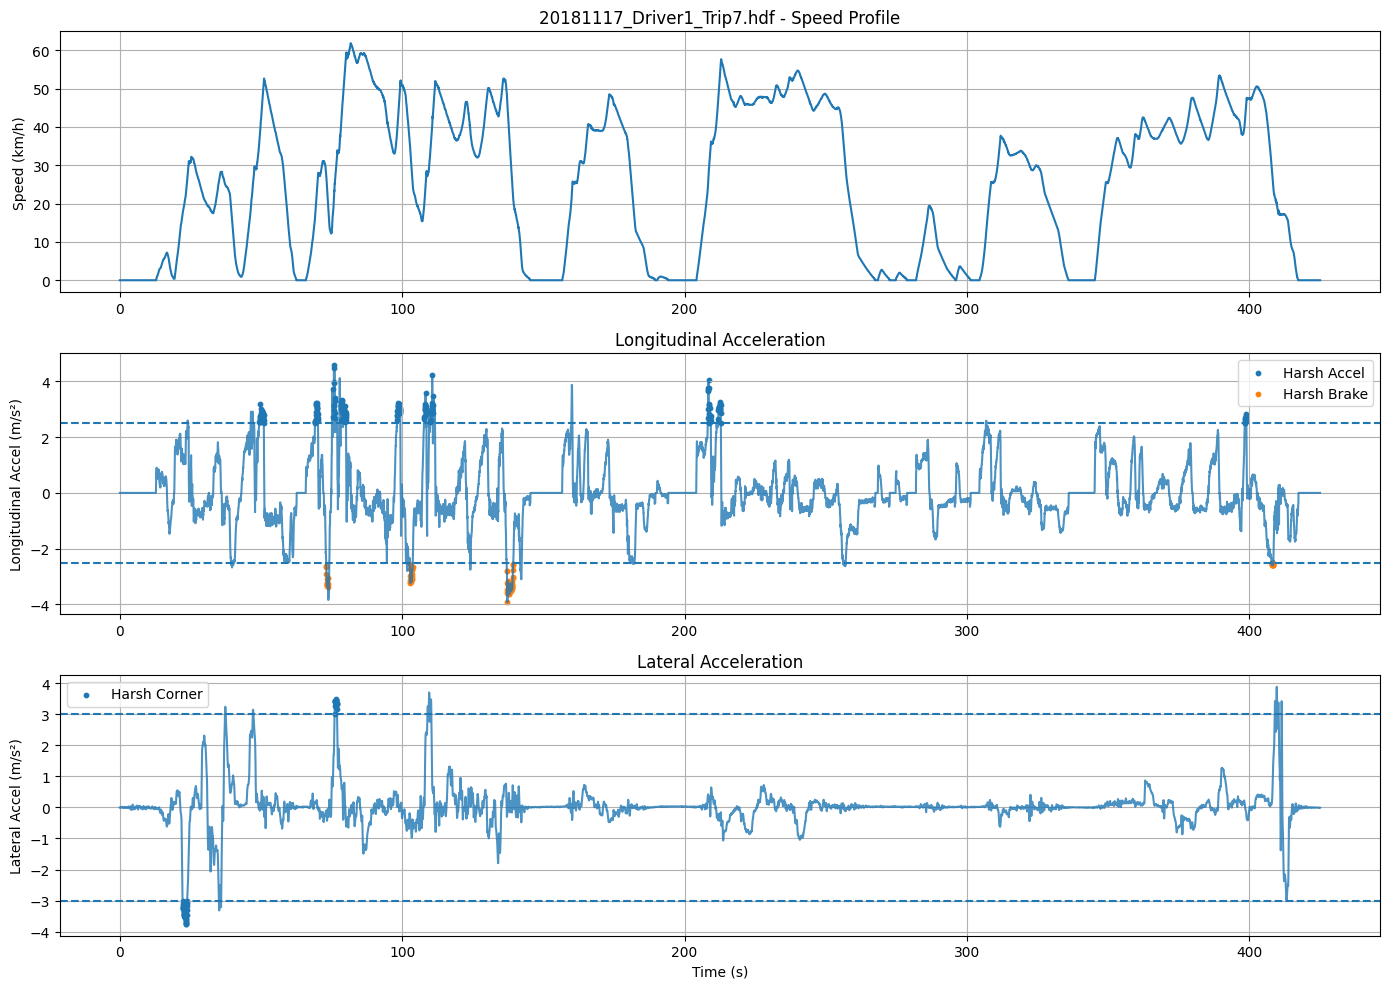

In [93]:
# =========================
# Visual Check on a Representative Trip
# =========================

trip_name = "20181117_Driver1_Trip7.hdf"
trip_df = df_all[df_all["trip"] == trip_name].copy().sort_values("time")

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Speed
axes[0].plot(trip_df["time"], trip_df["speed"])
axes[0].set_ylabel("Speed (km/h)")
axes[0].set_title(f"{trip_name} - Speed Profile")
axes[0].grid(True)

# Longitudinal acceleration
axes[1].plot(trip_df["time"], trip_df["accel_long_smooth"], alpha=0.8)
axes[1].scatter(
    trip_df.loc[trip_df["harsh_accel"] == 1, "time"],
    trip_df.loc[trip_df["harsh_accel"] == 1, "accel_long_smooth"],
    s=10,
    label="Harsh Accel"
)
axes[1].scatter(
    trip_df.loc[trip_df["harsh_brake"] == 1, "time"],
    trip_df.loc[trip_df["harsh_brake"] == 1, "accel_long_smooth"],
    s=10,
    label="Harsh Brake"
)
axes[1].axhline(HARSH_ACCEL_THRESHOLD, linestyle="--")
axes[1].axhline(HARSH_BRAKE_THRESHOLD, linestyle="--")
axes[1].set_ylabel("Longitudinal Accel (m/s²)")
axes[1].set_title("Longitudinal Acceleration")
axes[1].legend()
axes[1].grid(True)

# Lateral acceleration
axes[2].plot(trip_df["time"], trip_df["accel_lat_smooth"], alpha=0.8)
axes[2].scatter(
    trip_df.loc[trip_df["harsh_corner"] == 1, "time"],
    trip_df.loc[trip_df["harsh_corner"] == 1, "accel_lat_smooth"],
    s=10,
    label="Harsh Corner"
)
axes[2].axhline(HARSH_CORNER_LAT_THRESHOLD, linestyle="--")
axes[2].axhline(-HARSH_CORNER_LAT_THRESHOLD, linestyle="--")
axes[2].set_ylabel("Lateral Accel (m/s²)")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Lateral Acceleration")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [94]:
# =========================
# Preview of Labeled Data
# =========================

df_all[[
    "trip", "time", "speed",
    "accel_long_smooth", "accel_lat_smooth", "yaw_rate_smooth",
    "harsh_accel", "harsh_brake", "harsh_corner", "aggressive"
]].head(20)

,trip,time,speed,accel_long_smooth,accel_lat_smooth,yaw_rate_smooth,harsh_accel,harsh_brake,harsh_corner,aggressive
0,20181113_Driver1_Trip1.hdf,0.00,0.0,0.0,0.009315,0.008962,0,0,0,0
1,20181113_Driver1_Trip1.hdf,0.05,0.0,0.0,0.009347,0.007478,0,0,0,0
2,20181113_Driver1_Trip1.hdf,0.10,0.0,0.0,0.002687,0.000198,0,0,0,0
3,20181113_Driver1_Trip1.hdf,0.15,0.0,0.0,-0.000630,-0.010664,0,0,0,0
4,20181113_Driver1_Trip1.hdf,0.20,0.0,0.0,-0.000749,-0.004573,0,0,0,0
5,20181113_Driver1_Trip1.hdf,0.25,0.0,0.0,-0.004681,-0.000578,0,0,0,0
6,20181113_Driver1_Trip1.hdf,0.30,0.0,0.0,-0.007189,0.006297,0,0,0,0
7,20181113_Driver1_Trip1.hdf,0.35,0.0,0.0,-0.004326,0.011988,0,0,0,0
8,20181113_Driver1_Trip1.hdf,0.40,0.0,0.0,-0.000919,0.013165,0,0,0,0
9,20181113_Driver1_Trip1.hdf,0.45,0.0,0.0,-0.004915,0.011456,0,0,0,0


## Window-Based Feature Extraction

To move from raw sample-level signals to a compact machine learning dataset, the trip data is segmented into fixed-length windows.  
For each window, statistical features are extracted from speed, RPM, throttle, acceleration, yaw rate, and jerk signals.

A binary aggressive-driving label is then assigned to each window based on whether any harsh event occurs within that window.

In [95]:
# =========================
# Window Configuration
# =========================

WINDOW_SIZE = 100   # 5 seconds at 20 Hz
STEP_SIZE = 100     # non-overlapping windows

In [96]:
# =========================
# Feature Extraction from Fixed Windows
# =========================

def extract_window_features(trip_df, window_size=100, step_size=100):
    """
    Extract statistical features from fixed windows for driver behavior classification.
    """
    trip_df = trip_df.sort_values("time").reset_index(drop=True)
    rows = []

    for start in range(0, len(trip_df) - window_size + 1, step_size):
        w = trip_df.iloc[start:start + window_size]

        row = {
            "trip": w["trip"].iloc[0],
            "start_time": w["time"].iloc[0],
            "end_time": w["time"].iloc[-1],

            # Speed features
            "speed_mean": w["speed"].mean(),
            "speed_std": w["speed"].std(),
            "speed_min": w["speed"].min(),
            "speed_max": w["speed"].max(),
            "speed_p10": w["speed"].quantile(0.10),
            "speed_p90": w["speed"].quantile(0.90),

            # RPM features
            "rpm_mean": w["rpm"].mean(),
            "rpm_std": w["rpm"].std(),
            "rpm_max": w["rpm"].max(),

            # Throttle features
            "throttle_mean": w["throttle"].mean(),
            "throttle_std": w["throttle"].std(),
            "throttle_max": w["throttle"].max(),

            # Longitudinal acceleration features
            "accel_long_mean": w["accel_long_smooth"].mean(),
            "accel_long_std": w["accel_long_smooth"].std(),
            "accel_long_min": w["accel_long_smooth"].min(),
            "accel_long_max": w["accel_long_smooth"].max(),
            "accel_long_p90": w["accel_long_smooth"].quantile(0.90),
            "accel_long_p10": w["accel_long_smooth"].quantile(0.10),

            # Lateral acceleration features
            "accel_lat_mean": w["accel_lat_smooth"].mean(),
            "accel_lat_std": w["accel_lat_smooth"].std(),
            "accel_lat_min": w["accel_lat_smooth"].min(),
            "accel_lat_max": w["accel_lat_smooth"].max(),
            "accel_lat_p90": w["accel_lat_smooth"].quantile(0.90),
            "accel_lat_p10": w["accel_lat_smooth"].quantile(0.10),

            # Yaw rate features
            "yaw_mean": w["yaw_rate_smooth"].mean(),
            "yaw_std": w["yaw_rate_smooth"].std(),
            "yaw_max": w["yaw_rate_smooth"].abs().max(),

            # Placeholder jerk features
            "jerk_long_std": 0.0,
            "jerk_long_maxabs": 0.0,
            "jerk_lat_std": 0.0,
            "jerk_lat_maxabs": 0.0,

            # Window labels
            "label_accel": int(w["harsh_accel"].any()),
            "label_brake": int(w["harsh_brake"].any()),
            "label_corner": int(w["harsh_corner"].any()),
        }

        jerk_long = np.diff(w["accel_long_smooth"].values) / 0.05
        jerk_lat = np.diff(w["accel_lat_smooth"].values) / 0.05

        if len(jerk_long) > 0:
            row["jerk_long_std"] = np.std(jerk_long)
            row["jerk_long_maxabs"] = np.max(np.abs(jerk_long))

        if len(jerk_lat) > 0:
            row["jerk_lat_std"] = np.std(jerk_lat)
            row["jerk_lat_maxabs"] = np.max(np.abs(jerk_lat))

        row["label_aggressive"] = int(
            row["label_accel"] or row["label_brake"] or row["label_corner"]
        )

        rows.append(row)

    return pd.DataFrame(rows)

## Extract Window Features Across All Trips

The feature-extraction routine is applied to each trip independently, and the resulting window-level records are combined into a single machine learning dataset.

In [97]:
# =========================
# Build Window-Level Dataset
# =========================

window_dfs = []

for trip_name, trip_df in df_all.groupby("trip"):
    trip_windows = extract_window_features(
        trip_df,
        window_size=WINDOW_SIZE,
        step_size=STEP_SIZE
    )
    window_dfs.append(trip_windows)

windows_df = pd.concat(window_dfs, ignore_index=True)
windows_df["driver"] = windows_df["trip"].str.extract(r"(Driver\d+)")[0]

print(f"Total windows: {len(windows_df):,}")
print(f"Total columns: {windows_df.shape[1]}")
windows_df.head()

Total windows: 8,720
Total columns: 39


,trip,start_time,end_time,speed_mean,speed_std,speed_min,speed_max,speed_p10,speed_p90,rpm_mean,...,yaw_max,jerk_long_std,jerk_long_maxabs,jerk_lat_std,jerk_lat_maxabs,label_accel,label_brake,label_corner,label_aggressive,driver
0,20181113_Driver1_Trip1.hdf,0.0,4.950000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,799.909546,...,0.033131,0.000000,0.000000,0.111351,0.296781,0,0,0,0,Driver1
1,20181113_Driver1_Trip1.hdf,5.0,9.950000,0.042162,0.162970,0.000000,0.840000,0.000000,0.000000,892.505493,...,1.781642,1.069703,7.241548,0.117208,0.283206,0,0,0,0,Driver1
2,20181113_Driver1_Trip1.hdf,10.0,14.950000,9.095517,5.315007,0.950000,18.956934,2.124394,16.734277,1398.651123,...,6.202372,1.205687,3.217265,0.393973,1.158756,0,0,0,0,Driver1
3,20181113_Driver1_Trip1.hdf,15.0,19.950001,18.954992,0.471430,18.453018,20.078800,18.559999,19.751000,1397.403320,...,1.154376,1.522342,5.535982,0.632663,1.813304,0,0,0,0,Driver1
4,20181113_Driver1_Trip1.hdf,20.0,24.950001,24.830723,3.812906,18.559999,28.799999,19.001716,28.740000,1631.858765,...,2.181088,1.471046,4.211338,1.123489,2.699906,0,0,0,0,Driver1


## Window-Level Label Distribution

Before model training, the class distribution is inspected to understand the balance between normal and aggressive windows.

In [98]:
# =========================
# Window Label Distribution
# =========================

windows_df["label_aggressive"].value_counts()

,count
label_aggressive,
0,8416
1,304


In [99]:
# =========================
# Label Proportions
# =========================

windows_df["label_aggressive"].value_counts(normalize=True)

,proportion
label_aggressive,
0,0.965138
1,0.034862


In [100]:
# =========================
# Per-Event Window Label Summary
# =========================

for col in ["label_accel", "label_brake", "label_corner", "label_aggressive"]:
    print(f"\n{col}")
    print(windows_df[col].value_counts())
    print(windows_df[col].value_counts(normalize=True))


label_accel
label_accel
0    8596
1     124
Name: count, dtype: int64
label_accel
0    0.98578
1    0.01422
Name: proportion, dtype: float64

label_brake
label_brake
0    8640
1      80
Name: count, dtype: int64
label_brake
0    0.990826
1    0.009174
Name: proportion, dtype: float64

label_corner
label_corner
0    8593
1     127
Name: count, dtype: int64
label_corner
0    0.985436
1    0.014564
Name: proportion, dtype: float64

label_aggressive
label_aggressive
0    8416
1     304
Name: count, dtype: int64
label_aggressive
0    0.965138
1    0.034862
Name: proportion, dtype: float64


## Define Input Features and Target Label

Non-predictive identifiers and label columns are excluded so that the remaining columns can be used as model inputs.

In [101]:
# =========================
# Define Inputs, Target, and Groups
# =========================

target_col = "label_aggressive"

exclude_cols = [
    "trip", "start_time", "end_time", "driver",
    "label_accel", "label_brake", "label_corner", "label_aggressive"
]

feature_cols = [c for c in windows_df.columns if c not in exclude_cols]

X = windows_df[feature_cols].copy()
y = windows_df[target_col].copy()
groups = windows_df["trip"].copy()

print(f"Number of features: {len(feature_cols)}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Aggressive windows: {y.sum()} ({100 * y.mean():.2f}%)")

Number of features: 31
X shape: (8720, 31)
y shape: (8720,)
Aggressive windows: 304 (3.49%)


## Group-Aware Train, Validation, and Test Split

Because windows from the same trip are highly correlated, the split is performed at the trip level rather than the individual-window level.  
This helps prevent leakage between training and evaluation sets.

In [102]:
# =========================
# Group-Based Train / Validation / Test Split
# =========================

from sklearn.model_selection import GroupShuffleSplit

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
temp_idx, test_idx = next(gss_test.split(X, y, groups=groups))

X_temp = X.iloc[temp_idx]
y_temp = y.iloc[temp_idx]
groups_temp = groups.iloc[temp_idx]

X_test = X.iloc[test_idx]
y_test = y.iloc[test_idx]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.22, random_state=42)
train_idx, val_idx = next(gss_val.split(X_temp, y_temp, groups=groups_temp))

X_train = X_temp.iloc[train_idx]
y_train = y_temp.iloc[train_idx]

X_val = X_temp.iloc[val_idx]
y_val = y_temp.iloc[val_idx]

In [103]:
# =========================
# Split Summary
# =========================

temp_trips_df = windows_df.iloc[temp_idx]
train_trips = temp_trips_df.iloc[train_idx]["trip"].nunique()
val_trips = temp_trips_df.iloc[val_idx]["trip"].nunique()
test_trips = windows_df.iloc[test_idx]["trip"].nunique()

print("TRAIN / VALIDATION / TEST SPLIT")
print(f"Train:      {X_train.shape[0]} windows, {train_trips} trips, {100*y_train.mean():.2f}% aggressive")
print(f"Validation: {X_val.shape[0]} windows, {val_trips} trips, {100*y_val.mean():.2f}% aggressive")
print(f"Test:       {X_test.shape[0]} windows, {test_trips} trips, {100*y_test.mean():.2f}% aggressive")
print(f"Total:      {len(X)} windows, {windows_df['trip'].nunique()} trips")

TRAIN / VALIDATION / TEST SPLIT
Train:      4618 windows, 12 trips, 4.53% aggressive
Validation: 1055 windows, 4 trips, 3.03% aggressive
Test:       3047 windows, 5 trips, 2.07% aggressive
Total:      8720 windows, 21 trips


## Classical Baseline Models

Before moving to neural networks, a small set of classical machine learning models is evaluated to establish baseline performance on the engineered feature set.

In [104]:
# =========================
# Define Baseline Models
# =========================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix

models = {
    "logreg": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        ))
    ]),

    "tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", DecisionTreeClassifier(
            max_depth=6,
            min_samples_leaf=10,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "rf": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "mlp": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=400,
            random_state=42
        ))
    ])
}

In [105]:
# =========================
# Validation Evaluation
# =========================

val_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    val_results.append({
        "model": name,
        "val_accuracy": accuracy_score(y_val, y_val_pred),
        "val_f1": f1_score(y_val, y_val_pred)
    })

val_results_df = pd.DataFrame(val_results).sort_values("val_f1", ascending=False)
val_results_df

,model,val_accuracy,val_f1
2,rf,0.981991,0.753247
3,mlp,0.980095,0.740741
0,logreg,0.944076,0.512397
1,tree,0.943128,0.508197


In [106]:
# =========================
# Best Model Selection and Test Evaluation
# =========================

best_model_name = val_results_df.iloc[0]["model"]
best_model = models[best_model_name]

best_model.fit(X_train, y_train)
y_test_pred = best_model.predict(X_test)

print(f"Best model: {best_model_name}")
print(f"Test accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Test F1: {f1_score(y_test, y_test_pred):.4f}")
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred, digits=4))

Best model: rf
Test accuracy: 0.9954
Test F1: 0.8852
[[2979    5]
 [   9   54]]
              precision    recall  f1-score   support

           0     0.9970    0.9983    0.9977      2984
           1     0.9153    0.8571    0.8852        63

    accuracy                         0.9954      3047
   macro avg     0.9561    0.9277    0.9415      3047
weighted avg     0.9953    0.9954    0.9953      3047



## Optional Model Comparison Visualizations

The following plots are useful for analysis, but they are optional in a GitHub-facing notebook.  
If the notebook should stay compact, keep only the feature-importance plot and remove the rest.

In [107]:
# =========================
# Random Forest Feature Importance
# =========================

rf_model = models["rf"].named_steps["clf"]

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
13,accel_long_std,0.168368
1,speed_std,0.085420
14,accel_long_min,0.073762
15,accel_long_max,0.064631
26,yaw_max,0.061802
16,accel_long_p90,0.043793
7,rpm_std,0.042973
27,jerk_long_std,0.042404
21,accel_lat_max,0.035395
18,accel_lat_mean,0.034436


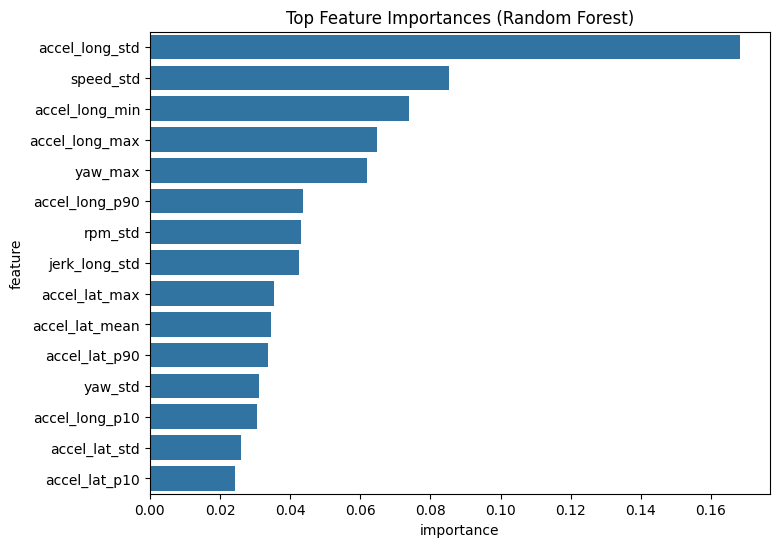

In [108]:
# =========================
# Plot Top Feature Importances
# =========================

import matplotlib.pyplot as plt
import seaborn as sns

top = importance_df.head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=top, x="importance", y="feature")
plt.title("Top Feature Importances (Random Forest)")
plt.show()

## Reduced Feature Set for Embedded Deployment

To support compact embedded deployment, a smaller feature subset is selected based on feature importance.  
This reduced representation is intended to lower computational cost while preserving predictive performance.

In [109]:
# =========================
# Select Reduced Feature Set
# =========================

small_feature_cols = [
    "accel_long_std",
    "speed_std",
    "accel_long_min",
    "accel_long_max",
    "yaw_max",
    "accel_long_p90"
]

X_small = windows_df[small_feature_cols].copy()
y_small = windows_df["label_aggressive"].copy()
groups_small = windows_df["trip"].copy()

print(f"X_small shape: {X_small.shape}")
print(f"y_small shape: {y_small.shape}")
print(f"Aggressive rate: {100 * y_small.mean():.2f}%")
print(small_feature_cols)

X_small shape: (8720, 6)
y_small shape: (8720,)
Aggressive rate: 3.49%
['accel_long_std', 'speed_std', 'accel_long_min', 'accel_long_max', 'yaw_max', 'accel_long_p90']


## Transition to Neural Networks

Having established a compact reduced feature set, the next step is to train a neural network model using these selected inputs.

A neural network is used at this stage because:

- it can model nonlinear relationships between driving features and aggressive behavior
- it remains lightweight enough to be reduced and exported for embedded inference
- it provides a better pathway to TensorFlow Lite conversion and deployment on the ESP32 than most classical models
- it supports a compact architecture that is more suitable for resource-constrained hardware

The following section therefore focuses on neural-network training, evaluation, and export for embedded deployment.

In [110]:
import numpy as np
import pandas as pd

# ============================================================================
# SELECT TOP 6 FEATURES FROM FEATURE IMPORTANCE PLOT
# ============================================================================

small_feature_cols = [
    "accel_long_std",      # #1 - Most important!
    "speed_std",           # #2
    "accel_long_min",      # #3
    "accel_long_max",      # #4
    "yaw_max",             # #5
    "accel_long_p90"       # #6
]

X_small = windows_df[small_feature_cols].copy()
y_small = windows_df["label_aggressive"].copy()
groups = windows_df["trip"].copy()

print("="*60)
print("REDUCED FEATURE SET (Top 6 Features)")
print("="*60)
print(f"X shape: {X_small.shape}")
print(f"y shape: {y_small.shape}")
print(f"Aggressive rate: {100*y_small.mean():.2f}%")
print(f"\nFeatures:")
for i, feat in enumerate(small_feature_cols, 1):
    print(f"  {i}. {feat}")

REDUCED FEATURE SET (Top 6 Features)
X shape: (8720, 6)
y shape: (8720,)
Aggressive rate: 3.49%

Features:
  1. accel_long_std
  2. speed_std
  3. accel_long_min
  4. accel_long_max
  5. yaw_max
  6. accel_long_p90


## Neural Network Training on the Reduced Feature Set

After identifying a compact reduced feature set, a small neural network is trained for aggressive-driving classification.

This stage focuses on:
- group-aware data splitting
- feature standardization
- class imbalance handling
- neural-network training and evaluation
- export to TensorFlow Lite for embedded deployment

In [111]:
# =========================
# Group-Based Split for Reduced Feature Set
# =========================

from sklearn.model_selection import GroupShuffleSplit

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
temp_idx, test_idx = next(gss_test.split(X_small, y_small, groups=groups_small))

X_temp = X_small.iloc[temp_idx]
y_temp = y_small.iloc[temp_idx]
groups_temp = groups_small.iloc[temp_idx]

X_test_s = X_small.iloc[test_idx]
y_test_s = y_small.iloc[test_idx]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.22, random_state=42)
train_idx, val_idx = next(gss_val.split(X_temp, y_temp, groups=groups_temp))

X_train_s = X_temp.iloc[train_idx]
y_train_s = y_temp.iloc[train_idx]

X_val_s = X_temp.iloc[val_idx]
y_val_s = y_temp.iloc[val_idx]

In [113]:
# =========================
# Split Summary
# =========================

temp_trips_df = windows_df.iloc[temp_idx]
train_trips = temp_trips_df.iloc[train_idx]["trip"].nunique()
val_trips = temp_trips_df.iloc[val_idx]["trip"].nunique()
test_trips = windows_df.iloc[test_idx]["trip"].nunique()

print("TRAIN / VALIDATION / TEST SPLIT (Reduced Feature Set)")
print(f"Train:      {X_train_s.shape[0]} windows, {train_trips} trips, {100 * y_train_s.mean():.2f}% aggressive")
print(f"Validation: {X_val_s.shape[0]} windows, {val_trips} trips, {100 * y_val_s.mean():.2f}% aggressive")
print(f"Test:       {X_test_s.shape[0]} windows, {test_trips} trips, {100 * y_test_s.mean():.2f}% aggressive")

TRAIN / VALIDATION / TEST SPLIT (Reduced Feature Set)
Train:      4618 windows, 12 trips, 4.53% aggressive
Validation: 1055 windows, 4 trips, 3.03% aggressive
Test:       3047 windows, 5 trips, 2.07% aggressive


## Feature Scaling

The reduced feature set is standardized using statistics computed from the training set only.  
The same scaler is then applied to the validation and test sets.

In [114]:
# =========================
# Standardize Features
# =========================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_s)
X_val_scaled = scaler.transform(X_val_s)
X_test_scaled = scaler.transform(X_test_s)

print(f"Scaled train shape: {X_train_scaled.shape}")
print(f"Scaled validation shape: {X_val_scaled.shape}")
print(f"Scaled test shape: {X_test_scaled.shape}")

Scaled train shape: (4618, 6)
Scaled validation shape: (1055, 6)
Scaled test shape: (3047, 6)


## Class Imbalance Handling

Because aggressive windows are relatively rare, class weights are computed from the training set and used during neural-network training.

In [115]:
# =========================
# Compute Class Weights
# =========================

from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_s
)

class_weight = {
    0: float(weights[0]),
    1: float(weights[1])
}

print("Class 0 (Normal):", round(class_weight[0], 4))
print("Class 1 (Aggressive):", round(class_weight[1], 4))
print("Ratio (1/0):", round(class_weight[1] / class_weight[0], 2))

Class 0 (Normal): 0.5237
Class 1 (Aggressive): 11.0478
Ratio (1/0): 21.1


## Define the Neural Network

A compact multilayer perceptron is used so that the model remains lightweight enough for embedded deployment while still capturing nonlinear relationships in the reduced feature set.

In [116]:
# =========================
# Define Neural Network
# =========================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

input_dim = X_train_scaled.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257 (1.00 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

## Train the Neural Network

Early stopping is used to reduce overfitting and restore the best-performing weights based on validation loss.

In [117]:
# =========================
# Train Neural Network
# =========================

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train_s,
    validation_data=(X_val_scaled, y_val_s),
    epochs=150,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8012 - auc: 0.7886 - loss: 0.5790 - precision: 0.1386 - recall: 0.6507 - val_accuracy: 0.6919 - val_auc: 0.9416 - val_loss: 0.4816 - val_precision: 0.0850 - val_recall: 0.9375
Epoch 2/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7774 - auc: 0.9279 - loss: 0.3702 - precision: 0.1567 - recall: 0.8947 - val_accuracy: 0.7109 - val_auc: 0.9701 - val_loss: 0.4584 - val_precision: 0.0950 - val_recall: 1.0000
Epoch 3/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8153 - auc: 0.9447 - loss: 0.3113 - precision: 0.1868 - recall: 0.9187 - val_accuracy: 0.7630 - val_auc: 0.9709 - val_loss: 0.4098 - val_precision: 0.1135 - val_recall: 1.0000
Epoch 4/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8471 - auc: 0.9501 - loss: 0.2863 - precision: 0.2186 - recall: 0.9234 - val_accuracy: 0.7810 - val_auc: 0.9721 - val_loss: 0.3983 - val_precision: 0.1217 - val_recall: 1.0000
Epoch 5/150
145/145 ━━━━━━━

## Evaluate on the Test Set

The trained neural network is evaluated using accuracy, F1-score, confusion matrix, and classification metrics.

In [118]:
# =========================
# Test-Set Evaluation
# =========================

test_results = model.evaluate(X_test_scaled, y_test_s, verbose=0)

print("Test loss:", round(test_results[0], 4))
print("Test accuracy:", round(test_results[1], 4))
print("Test AUC:", round(test_results[2], 4))
print("Test precision:", round(test_results[3], 4))
print("Test recall:", round(test_results[4], 4))

Test loss: 0.1221
Test accuracy: 0.9111
Test AUC: 0.9517
Test precision: 0.1645
Test recall: 0.8095


In [119]:
# =========================
# Classification Metrics
# =========================

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

y_prob = model.predict(X_test_scaled).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("Accuracy:", round(accuracy_score(y_test_s, y_pred), 4))
print("F1:", round(f1_score(y_test_s, y_pred), 4))
print(confusion_matrix(y_test_s, y_pred))
print(classification_report(y_test_s, y_pred, digits=4))

96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.9111
F1: 0.2735
[[2725  259]
 [  12   51]]
              precision    recall  f1-score   support

           0     0.9956    0.9132    0.9526      2984
           1     0.1645    0.8095    0.2735        63

    accuracy                         0.9111      3047
   macro avg     0.5801    0.8614    0.6130      3047
weighted avg     0.9784    0.9111    0.9386      3047



## Training Curves

The training history is visualized to inspect convergence behavior and compare training and validation performance.

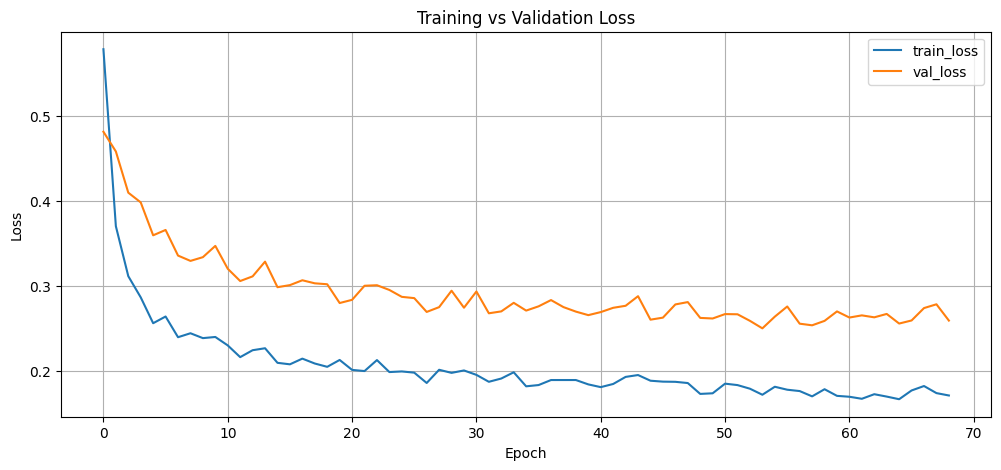

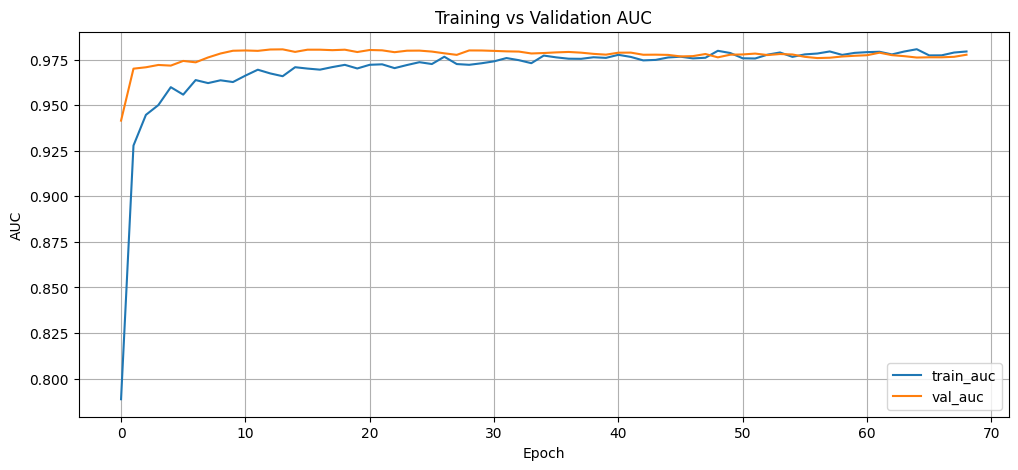

In [120]:
# =========================
# Plot Training History
# =========================

import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history.history)

plt.figure(figsize=(12, 5))
plt.plot(hist_df["loss"], label="train_loss")
plt.plot(hist_df["val_loss"], label="val_loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(hist_df["auc"], label="train_auc")
plt.plot(hist_df["val_auc"], label="val_auc")
plt.title("Training vs Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()

## Confusion Matrix

A confusion matrix is plotted to visualize the classification outcomes on the test set.

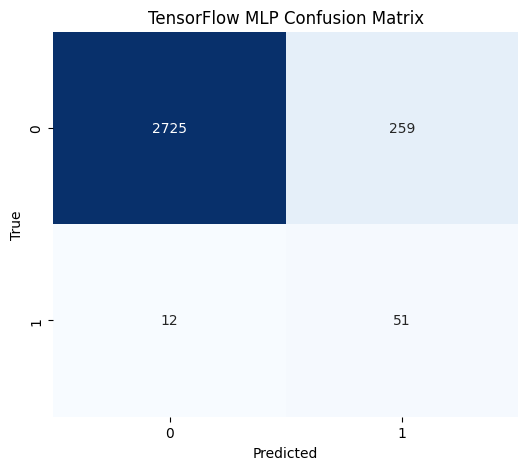

In [121]:
# =========================
# Plot Confusion Matrix
# =========================

import seaborn as sns

cm = confusion_matrix(y_test_s, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("TensorFlow MLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## Save Model and Scaler Parameters

The trained Keras model and feature-scaling parameters are saved for later conversion and embedded deployment.

In [122]:
# =========================
# Save Scaler Parameters
# =========================

scaler_params = pd.DataFrame({
    "feature": small_feature_cols,
    "mean": scaler.mean_,
    "scale": scaler.scale_
})

scaler_params

,feature,mean,scale
0,accel_long_std,0.324765,0.341399
1,speed_std,1.790878,2.183612
2,accel_long_min,-0.629786,0.754018
3,accel_long_max,0.626424,0.953253
4,yaw_max,3.074747,5.924069
5,accel_long_p90,0.406486,0.695420


In [123]:
# =========================
# Export Training Artifacts
# =========================

scaler_params.to_csv("scaler_params_small_mlp.csv", index=False)
model.save("tiny_driver_mlp.keras")

## Convert the Model to TensorFlow Lite

The trained Keras model is first exported as a float TensorFlow Lite model and then evaluated to confirm consistency with the original network.

In [124]:
# =========================
# Export Float TFLite Model
# =========================

import os

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

float_tflite_path = "tiny_driver_mlp_float.tflite"

with open(float_tflite_path, "wb") as f:
    f.write(tflite_model)

print("Saved:", float_tflite_path)
print("Size (bytes):", os.path.getsize(float_tflite_path))
print("Size (KB):", os.path.getsize(float_tflite_path) / 1024)

Saved artifact at '/tmp/tmpq4y6g8do'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='keras_tensor_5')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140580900401616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140580900402192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140580900402768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140580900403152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140580900401808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140580900399312: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved: tiny_driver_mlp_float.tflite
Size (bytes): 3112
Size (KB): 3.0390625


In [125]:
# =========================
# Evaluate Float TFLite Model
# =========================

from sklearn.metrics import roc_auc_score, average_precision_score

interpreter = tf.lite.Interpreter(model_path=float_tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

y_prob_tflite = []

for i in range(len(X_test_scaled)):
    x = X_test_scaled[i:i+1].astype(np.float32)
    interpreter.set_tensor(input_details[0]["index"], x)
    interpreter.invoke()
    y_out = interpreter.get_tensor(output_details[0]["index"])
    y_prob_tflite.append(y_out[0][0])

y_prob_tflite = np.array(y_prob_tflite)
y_pred_tflite = (y_prob_tflite >= 0.5).astype(int)

print("TFLite float accuracy:", round(accuracy_score(y_test_s, y_pred_tflite), 4))
print("TFLite float F1:", round(f1_score(y_test_s, y_pred_tflite), 4))
print("TFLite float AUC:", round(roc_auc_score(y_test_s, y_prob_tflite), 4))
print("TFLite float AP:", round(average_precision_score(y_test_s, y_prob_tflite), 4))

TFLite float accuracy: 0.9111
TFLite float F1: 0.2735
TFLite float AUC: 0.9518
TFLite float AP: 0.3457


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## Quantize the Model for Embedded Deployment

To reduce model size and improve embedded compatibility, the TensorFlow Lite model is quantized to INT8 using representative training samples.

In [126]:
# =========================
# Representative Dataset for Quantization
# =========================

def representative_data_gen():
    for i in range(min(500, len(X_train_scaled))):
        x = X_train_scaled[i:i+1].astype(np.float32)
        yield [x]

In [127]:
# =========================
# Export Quantized INT8 TFLite Model
# =========================

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

quant_tflite_model = converter.convert()

quant_tflite_path = "tiny_driver_mlp_int8.tflite"

with open(quant_tflite_path, "wb") as f:
    f.write(quant_tflite_model)

print("Saved:", quant_tflite_path)
print("Size (bytes):", os.path.getsize(quant_tflite_path))
print("Size (KB):", os.path.getsize(quant_tflite_path) / 1024)

Saved artifact at '/tmp/tmpbens8fdk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='keras_tensor_5')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140580900401616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140580900402192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140580900402768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140580900403152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140580900401808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140580900399312: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved: tiny_driver_mlp_int8.tflite
Size (bytes): 3392
Size (KB): 3.3125


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [128]:
# =========================
# Inspect Quantized Model I/O
# =========================

interpreter_q = tf.lite.Interpreter(model_path=quant_tflite_path)
interpreter_q.allocate_tensors()

input_details_q = interpreter_q.get_input_details()
output_details_q = interpreter_q.get_output_details()

print("Quantized input details:", input_details_q)
print("Quantized output details:", output_details_q)

Quantized input details: [{'name': 'serving_default_keras_tensor_5:0', 'index': 0, 'shape': array([1, 6], dtype=int32), 'shape_signature': array([-1,  6], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.038672614842653275, -19), 'quantization_parameters': {'scales': array([0.03867261], dtype=float32), 'zero_points': array([-19], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Quantized output details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 10, 'shape': array([1, 1], dtype=int32), 'shape_signature': array([-1,  1], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [129]:
# =========================
# Evaluate Quantized INT8 Model
# =========================

input_scale, input_zero_point = input_details_q[0]["quantization"]
output_scale, output_zero_point = output_details_q[0]["quantization"]

y_prob_q = []

for i in range(len(X_test_scaled)):
    x = X_test_scaled[i:i+1].astype(np.float32)
    x_q = np.round(x / input_scale + input_zero_point).astype(np.int8)

    interpreter_q.set_tensor(input_details_q[0]["index"], x_q)
    interpreter_q.invoke()

    y_out_q = interpreter_q.get_tensor(output_details_q[0]["index"])
    y_out_float = (y_out_q.astype(np.float32) - output_zero_point) * output_scale
    y_prob_q.append(y_out_float[0][0])

y_prob_q = np.array(y_prob_q)
y_pred_q = (y_prob_q >= 0.5).astype(int)

print("TFLite int8 accuracy:", round(accuracy_score(y_test_s, y_pred_q), 4))
print("TFLite int8 F1:", round(f1_score(y_test_s, y_pred_q), 4))
print("TFLite int8 AUC:", round(roc_auc_score(y_test_s, y_prob_q), 4))
print("TFLite int8 AP:", round(average_precision_score(y_test_s, y_prob_q), 4))

TFLite int8 accuracy: 0.9088
TFLite int8 F1: 0.276
TFLite int8 AUC: 0.9521
TFLite int8 AP: 0.3323


## Compare Model Variants

The Keras, float TensorFlow Lite, and quantized INT8 TensorFlow Lite versions are compared to verify that deployment conversion preserves predictive behavior.

In [130]:
# =========================
# Compare Keras and TFLite Variants
# =========================

compare_df = pd.DataFrame([
    {
        "model_version": "keras",
        "accuracy": accuracy_score(y_test_s, y_pred),
        "f1": f1_score(y_test_s, y_pred),
        "auc": roc_auc_score(y_test_s, y_prob),
        "ap": average_precision_score(y_test_s, y_prob)
    },
    {
        "model_version": "tflite_float",
        "accuracy": accuracy_score(y_test_s, y_pred_tflite),
        "f1": f1_score(y_test_s, y_pred_tflite),
        "auc": roc_auc_score(y_test_s, y_prob_tflite),
        "ap": average_precision_score(y_test_s, y_prob_tflite)
    },
    {
        "model_version": "tflite_int8",
        "accuracy": accuracy_score(y_test_s, y_pred_q),
        "f1": f1_score(y_test_s, y_pred_q),
        "auc": roc_auc_score(y_test_s, y_prob_q),
        "ap": average_precision_score(y_test_s, y_prob_q)
    }
])

compare_df

,model_version,accuracy,f1,auc,ap
0,keras,0.911060,0.273458,0.951759,0.345733
1,tflite_float,0.911060,0.273458,0.951759,0.345733
2,tflite_int8,0.908763,0.276042,0.952054,0.332281


## Export the Quantized Model as a C Header

The quantized TensorFlow Lite model is converted into a C header file so that it can be compiled directly into the ESP32 firmware.

In [131]:
# =========================
# Convert INT8 TFLite Model to C Header
# =========================

import subprocess

with open("tiny_driver_mlp_int8.h", "w") as out_file:
    subprocess.run(["xxd", "-i", quant_tflite_path], stdout=out_file)

## End of Training and Export Pipeline

At this point, the following deployment artifacts have been produced:

- trained Keras model
- scaler parameter file
- float TensorFlow Lite model
- quantized INT8 TensorFlow Lite model
- C header file for embedded deployment

These outputs form the bridge between model development in Python and real-time inference on the ESP32.